# Final Project (100)

**Group:2**

**Names:**

1. Ali Abughazaleh
2. Marvellous Oluwatola
3. Alec Degraaf
4. Xinshi Li
5. Sumit Belwal

---



# Directions
In the Final Project, which will be submitted in two parts, your group will perform text analytics to solve a real-world business problem. As a group, you will choose one of the following 5 business problems and accompanying dataset.

<br>

| Business Problem (Prediction)| Topic | Data Type | Dataset Name |
| ----------- | ----------- | ----------- | ----------- |
| Rating or Sentiment|Lotion|Online reviews|lotion-reviews.csv|
| Spam Detection|         |E-mails|spam.csv|
| Rating or Recommendation | Airlines| Customer surveys| airlines.csv|
| Rating| Weight Loss Drugs|Customer surveys| weightloss.csv|
| Rating| Amazon Products| Online reviews|amazon_reviews.csv|

<br>

First, type your group number and group member names in the text cells above. You will include all prerequisite code necessary for your code in Parts 1 and 2 to run in the [Prerequisite Code](#scrollTo=1NApcFUYjX8g) Section below.

Rename this template file - <b>INFO585_Final_Group#.ipynb</b>, where # is the assignment number. As an example, Group 1's Final Project submission would be named **INFO585_Final_Group1.ipynb**.

<br>

**Overview:**

<br>

**Part 1**

**Due:** 11/26 at 11:59 PM ET

In Part 1, you will define the business problem, cleanse and preprocess the data, and perform exploratory data analysis. To complete Part 1, you will fill in the required information in the [Part 1](#scrollTo=cwyEfhMwUTT1) Section.

<br>

**Part 2**

**Due:** 12/17 at 11:59 PM ET

In Part 2, you will perform predictive analysis, evaluate your predictive models, and make recommendations and discuss your results within the context of the business problem. To complete Part 2, you will fill include all required information for Part 1 and fill in the required information in the [Part 2](#scrollTo=8fZ_eKishBVo) Section.


<hr>
<br>

# Prerequisite Code

In [1]:
# Install required packages
!pip install wikipedia
!pip install nltk

# Import necessary libraries
import wikipedia
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_curve, auc, precision_recall_curve

from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences




  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=d0eb13151b817b4b115f5aadb8cc42f69b20cd74b52b491ed767d3066591a2b4
  Stored in directory: /root/.cache/pip/wheels/5e/b6/c5/93f3dec388ae76edc830cb42901bb0232504dfc0df02fc50de
Successfully built wikipedia


# Part 1 (50)

## Directions

Include your code and any required written information immediately under the relevant sections or prompts in the space provided.

You will submit your code and written responses in this .ipynb template notebook in the space provided under the sectioned prompts. Under the prompts there are code and/or text cells provided. If additional cells are needed, add the cells under the appropriate heading.

Your code and written responses should be easy for someone who did not write the code or perform the analysis to follow. Points will be deducted for extraneous code or if file naming instructions are not followed.

**Note:** Your Part 1 submission will only include responses for Part 1. Part 2 should remain blank or hidden in the Part 1 submission.

<br>

**Due:** 11/26 at 11:59 PM ET

**Points:** 50






## 1.1 Problem Definition & Statement (20)

**1.1 A (5) First, use the code cell below to identify your group's selected dataset and the target variable (column name) that will be used for predictive modeling.**

In [2]:
# @title Identify Problem/Dataset

Dataset = 'lotion-reviews.csv' # @param ["lotion-reviews.csv", "spam.csv", "airlines.csv", "weightloss.csv", "amazon_reviews.csv"]
Target_Variable = 'rating' # @param {type:"string"}

print(Dataset)
print(Target_Variable)


lotion-reviews.csv
rating


**1.1 B (15) Next, use the text cell below for your problem definition and statement.**

**The problem statement should discuss the following: what is the problem and who it affects, financial/social implications of having a solution to the problem, how the model would be used in practice, and the acceptable level of model performance.**


From the analysis of the lotion reviews, it's clear that the main issue is the varying quality of the lotion, particularly in terms of its fragrance and overall condition. This variability not only affects customer satisfaction but also has implications for the brand's reputation. Tackling this problem could lead to fewer returned products and stronger customer loyalty, financially benefiting the company. Additionally, it could enhance the brand’s reputation and increase overall customer happiness.

To address this, a text mining model will be implemented to thoroughly examine the reviews. Its focus will be on identifying customer sentiments, zeroing in on specific complaints, and detecting any consistent trends. This examination is crucial for improving the lotion's quality control and shaping customer service approaches. The effectiveness of the model hinges on its ability to accurately and reliably identify relevant information. We will assess the model's performance using measures such as overall accuracy, F1 score, and its capability to accurately determine sentiments. The ultimate objective is to convert the unstructured opinions of customers into clear, useful information that can inform product enhancements and guide strategic decisions in the skincare sector.

<hr>
<br>

## 1.2 Data: Cleansing and Preprocessing (15)


**1.2 A (10) Use the code cell below (and add any additional cells, as necessary) to cleanse and preprocess the data that you will use in your analysis.**

In [3]:
# file_path = '/content/lotion-reviews.csv'

# Load the data from the CSV file
reviews = pd.read_csv('lotion-reviews.csv')

reviews.head()


,review_date,handle,rating,helpfulness_rating,review
0,"December 7, 2018",Sandy Gonzalez,1.0,409,"This is my favorite moisturizer, and I think I..."
1,"August 26, 2018",BizzyEnuf,5.0,403,When deciding whether to buy the lotion or cre...
2,"September 13, 2018",Lindsay W.,1.0,317,I love this lotion and have been buying it for...
3,"June 6, 2018",Brandi Evans,1.0,246,The lotion smells weird after it dries. Others...
4,"May 16, 2018",pleinelune,5.0,117,5/2019 EDIT: STILL USING AND....it was great ...


In [4]:
# Examine the number of shape of the dataset

reviews.shape

(5000, 5)

In [5]:
# Checking for missing values in the 'review' column
missing_values = reviews['review'].isnull().sum()

# If there are missing values, we can choose to either fill them or drop them
# For this example, we choose to drop rows with missing reviews
if missing_values > 0:
   reviews_cleaned = reviews.dropna(subset=['review'])
else:
   reviews_cleaned = reviews.copy()

missing_values, reviews_cleaned.shape


(1, (4999, 5))

In [6]:
# Function for text normalization: lowercasing and removing punctuation
def normalize_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Apply the normalization function to the 'review' column
reviews_cleaned['review_normalized'] =reviews_cleaned['review'].apply(normalize_text)

# Display the first few rows to verify the changes
reviews_cleaned[['review', 'review_normalized']].head()


<ipython-input-6-db2276f407a8>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_cleaned['review_normalized'] =reviews_cleaned['review'].apply(normalize_text)


,review,review_normalized
0,"This is my favorite moisturizer, and I think I...",this is my favorite moisturizer and i think iv...
1,When deciding whether to buy the lotion or cre...,when deciding whether to buy the lotion or cre...
2,I love this lotion and have been buying it for...,i love this lotion and have been buying it for...
3,The lotion smells weird after it dries. Others...,the lotion smells weird after it dries others ...
4,5/2019 EDIT: STILL USING AND....it was great ...,52019 edit still using andit was great for wi...


In [7]:
import nltk
from nltk.tokenize import word_tokenize  # Import the word_tokenize function
from nltk.corpus import stopwords

# First, download the necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Then, define a function to process the text
def process_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Get English stop words
    stop_words = set(stopwords.words('english'))
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Apply the function to the 'review_normalized' column
# Make sure 'reviews_cleaned' and 'review_normalized' are defined and contain the data you want to process
reviews_cleaned['review_processed'] = reviews_cleaned['review_normalized'].apply(process_text)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
<ipython-input-7-158da42f2af2>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_cleaned['review_processed'] = reviews_cleaned['review_normalized'].apply(process_text)


In [8]:
from nltk.stem import WordNetLemmatizer

# we download the wordnet resource
nltk.download('wordnet')

# Initialize the WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

# Function to apply lemmatization
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply lemmatization to the 'review_processed' column
reviews_cleaned['review_lemmatized'] = reviews_cleaned['review_processed'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
<ipython-input-8-fef95708cfa3>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_cleaned['review_lemmatized'] = reviews_cleaned['review_processed'].apply(lemmatize_text)


In [9]:
from nltk.tokenize import word_tokenize


# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Get English stop words
stop_words = set(stopwords.words('english'))

# Function for tokenization and removing stop words
def process_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# Apply the text processing function to the 'review_normalized' column
reviews_cleaned['review_processed'] = reviews_cleaned['review_normalized'].apply(process_text)

# Display the first few rows to verify the changes
reviews_cleaned[['review', 'review_processed']].head()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
<ipython-input-9-634af4dd061b>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_cleaned['review_processed'] = reviews_cleaned['review_normalized'].apply(process_text)


,review,review_processed
0,"This is my favorite moisturizer, and I think I...","[favorite, moisturizer, think, ive, purchased,..."
1,When deciding whether to buy the lotion or cre...,"[deciding, whether, buy, lotion, cream, versio..."
2,I love this lotion and have been buying it for...,"[love, lotion, buying, years, last, bottle, bo..."
3,The lotion smells weird after it dries. Others...,"[lotion, smells, weird, dries, others, describ..."
4,5/2019 EDIT: STILL USING AND....it was great ...,"[52019, edit, still, using, andit, great, wint..."


In [10]:
reviews_cleaned.head()

,review_date,handle,rating,helpfulness_rating,review,review_normalized,review_processed,review_lemmatized
0,"December 7, 2018",Sandy Gonzalez,1.0,409,"This is my favorite moisturizer, and I think I...",this is my favorite moisturizer and i think iv...,"[favorite, moisturizer, think, ive, purchased,...","[favorite, moisturizer, think, ive, purchased,..."
1,"August 26, 2018",BizzyEnuf,5.0,403,When deciding whether to buy the lotion or cre...,when deciding whether to buy the lotion or cre...,"[deciding, whether, buy, lotion, cream, versio...","[deciding, whether, buy, lotion, cream, versio..."
2,"September 13, 2018",Lindsay W.,1.0,317,I love this lotion and have been buying it for...,i love this lotion and have been buying it for...,"[love, lotion, buying, years, last, bottle, bo...","[love, lotion, buying, year, last, bottle, bou..."
3,"June 6, 2018",Brandi Evans,1.0,246,The lotion smells weird after it dries. Others...,the lotion smells weird after it dries others ...,"[lotion, smells, weird, dries, others, describ...","[lotion, smell, weird, dry, others, described,..."
4,"May 16, 2018",pleinelune,5.0,117,5/2019 EDIT: STILL USING AND....it was great ...,52019 edit still using andit was great for wi...,"[52019, edit, still, using, andit, great, wint...","[52019, edit, still, using, andit, great, wint..."


In [11]:
#Cheking for missing values for the cleand reviews
print("\nDataFrame Information after removing missing values:\n")
print(reviews_cleaned.info())



DataFrame Information after removing missing values:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4999 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   review_date         4999 non-null   object 
 1   handle              4999 non-null   object 
 2   rating              4999 non-null   float64
 3   helpfulness_rating  1070 non-null   object 
 4   review              4999 non-null   object 
 5   review_normalized   4999 non-null   object 
 6   review_processed    4999 non-null   object 
 7   review_lemmatized   4999 non-null   object 
dtypes: float64(1), object(7)
memory usage: 351.5+ KB
None


In [12]:
# Drop the columns we will not use

reviews_cleaned.drop(['review_date','handle','helpfulness_rating', 'review', 'review_normalized', 'review_processed'], axis=1, inplace=True)

<ipython-input-12-47b41e626c14>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_cleaned.drop(['review_date','handle','helpfulness_rating', 'review', 'review_normalized', 'review_processed'], axis=1, inplace=True)


In [13]:
reviews_cleaned.head()

,rating,review_lemmatized
0,1.0,"[favorite, moisturizer, think, ive, purchased,..."
1,5.0,"[deciding, whether, buy, lotion, cream, versio..."
2,1.0,"[love, lotion, buying, year, last, bottle, bou..."
3,1.0,"[lotion, smell, weird, dry, others, described,..."
4,5.0,"[52019, edit, still, using, andit, great, wint..."


<ipython-input-14-53c61699eb1f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reviews_cleaned['sentiment'] = reviews_cleaned['rating'].replace({1:0, 2:0, 3:0, 4:1, 5:1})


<Axes: >

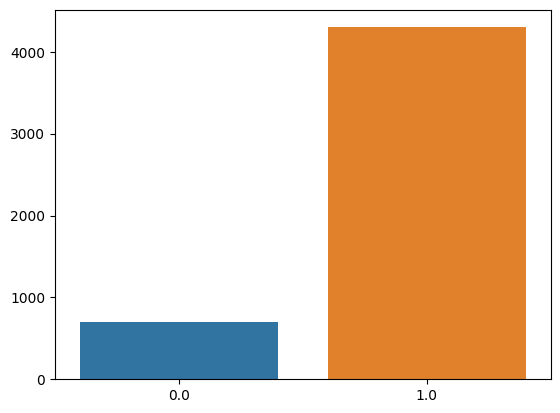

In [14]:
reviews_cleaned['sentiment'] = reviews_cleaned['rating'].replace({1:0, 2:0, 3:0, 4:1, 5:1})

sentiment_counts = reviews_cleaned['sentiment'].value_counts()

sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)

In [15]:
X = reviews_cleaned['review_lemmatized']
y = reviews_cleaned['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=123)

**1.2 B (5) In the text cell below, briefly describe and discuss (in paragraph format) the cleansing and preprocessing steps taken to prepare the data for analysis.**

To preprocess the "Lotion Reviews," the following steps were undertaken: First, the data were loaded and inspected to understand its structure. Subsequently, any missing values in the 'review' column were identified and removed to ensure the completeness of the data. Next, text normalization was carried out by converting all reviews to lowercase and removing punctuation, aiding in the standardization of the text. This was followed by tokenization, wherein the text was divided into individual words or tokens, allowing for a more detailed analysis. Post-tokenization, common stop words (such as "the," "is," and "and") were eliminated to focus on more meaningful words within the text. Optionally, one could also perform lemmatization or stemming to reduce words to their base or root form, which is what was done, thereby further refining the data for analysis. These steps collectively transformed the raw data into a clean, organized format suitable for text mining. Then, we assigned a value of 0 to ratings from 1 to 3 and a value of 1 to ratings from 4 to 5, effectively categorizing the reviews for binary analysis. Lastly, the data were partitioned into training and test sets.



---



## 1.3 Data: Description & EDA (15)





**1.3 A (8) Use the code cell below (and add any additional cells, as necessary) to describe the data and perform exploratory data analysis.**

**Description and EDA of the dataset should include: dataset overview, preview, dimensionality, visualization (text, target variable), descriptive statistics, and can include Cluster Analysis.**

In [16]:
file_path = '/content/lotion-reviews.csv'

# Load the data from the CSV file
reviews = pd.read_csv(file_path)

reviews.head()

,review_date,handle,rating,helpfulness_rating,review
0,"December 7, 2018",Sandy Gonzalez,1.0,409,"This is my favorite moisturizer, and I think I..."
1,"August 26, 2018",BizzyEnuf,5.0,403,When deciding whether to buy the lotion or cre...
2,"September 13, 2018",Lindsay W.,1.0,317,I love this lotion and have been buying it for...
3,"June 6, 2018",Brandi Evans,1.0,246,The lotion smells weird after it dries. Others...
4,"May 16, 2018",pleinelune,5.0,117,5/2019 EDIT: STILL USING AND....it was great ...


In [17]:
#Preview
# Display the first few rows of the dataset
print(reviews.head())

# Descriptive statistics
print(reviews.describe())


          review_date          handle  rating helpfulness_rating  \
0    December 7, 2018  Sandy Gonzalez     1.0                409   
1     August 26, 2018       BizzyEnuf     5.0                403   
2  September 13, 2018      Lindsay W.     1.0                317   
3        June 6, 2018    Brandi Evans     1.0                246   
4        May 16, 2018      pleinelune     5.0                117   

                                              review  
0  This is my favorite moisturizer, and I think I...  
1  When deciding whether to buy the lotion or cre...  
2  I love this lotion and have been buying it for...  
3  The lotion smells weird after it dries. Others...  
4  5/2019 EDIT:  STILL USING AND....it was great ...  
            rating
count  5000.000000
mean      4.483400
std       1.124445
min       1.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       5.000000


In [18]:
#Dimentionality
# Examine the number of shape of the dataset

reviews.shape

(5000, 5)

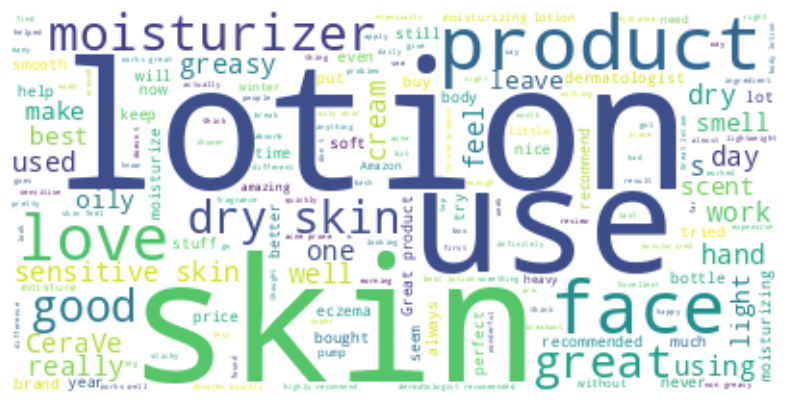

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all reviews into one large text
text = " ".join(review for review in reviews.review.dropna())

# Generate a word cloud image
wordcloud = WordCloud(background_color="white").generate(text)

# Display the generated image
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


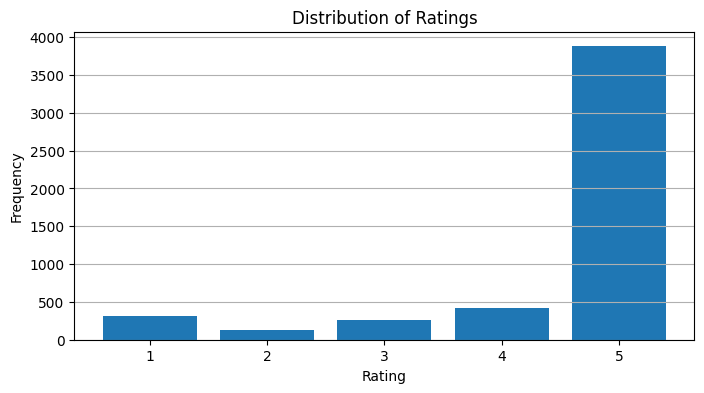

In [20]:
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame and it has a column named 'rating'
# Replace 'data' with the name of your DataFrame if it's different
rating_counts = reviews['rating'].value_counts()  # Count the occurrences of each rating

# Create a bar plot
plt.figure(figsize=(8, 4))
plt.bar(rating_counts.index, rating_counts.values)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks(rating_counts.index)  # Set the x-ticks to be the rating values
plt.grid(axis='y')
plt.show()



In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from nltk.corpus import stopwords

# Extracting features from the text
vectorizer = TfidfVectorizer(stop_words=stopwords.words('english'))
X = vectorizer.fit_transform(reviews['review'].dropna())

# Performing K-Means clustering
kmeans = KMeans(n_clusters=5, random_state=0).fit(X)

# Adding cluster labels to the original data
reviews_cleaned['cluster'] = kmeans.labels_

# Displaying the first few rows with cluster labels
print(reviews_cleaned.head())


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


   rating                                  review_lemmatized  sentiment  \
0     1.0  [favorite, moisturizer, think, ive, purchased,...        0.0   
1     5.0  [deciding, whether, buy, lotion, cream, versio...        1.0   
2     1.0  [love, lotion, buying, year, last, bottle, bou...        0.0   
3     1.0  [lotion, smell, weird, dry, others, described,...        0.0   
4     5.0  [52019, edit, still, using, andit, great, wint...        1.0   

   cluster  
0        1  
1        2  
2        1  
3        1  
4        2  


**1.3 B (7) In the text cell below, describe (in paragraph format) the dataset and any important findings from your description and EDA. A discussion of class imbalance should also be included if present.**


The lotion-reviews dataset presents a rich tapestry of consumer opinions centered around lotion products, as evidenced through meticulous exploratory data analysis (EDA). The dataset, which encapsulates 5,000 rows, each offering a glimpse into individual sentiments, is particularly telling in its numerical and textual feedback. A notable finding from the EDA is a significant class imbalance within the ratings variable, with a pronounced skew towards the highest rating of 5. This suggests that while users who provide feedback are generally very satisfied, there may be a potential bias towards positive reviews, or it could reflect a tendency for more satisfied customers to post reviews.

Descriptive statistics further bolster the narrative of customer satisfaction, with an average rating hovering around 4.48, indicating that negative reviews are relatively sparse. In the visual realm, a word cloud generated from the review texts illuminates key terms such as "moisturizer," "skin," "dry," and "great," showcasing the product's moisturizing efficacy and suitability for dry skin as common threads in consumer discussions. The prominence of positive adjectives in the word cloud, alongside the high ratings, paints a picture of a customer base that is largely pleased with their purchases, frequently recommending the products and applauding their benefits.

However, the class imbalance observed necessitates a cautious approach to analysis and any subsequent predictive modeling. It is critical to consider that the dataset may not fully capture the spectrum of less satisfied customer experiences, which are underrepresented in the reviews. Thus, while the data provides valuable insights into what drives satisfaction among reviewers, it also highlights the importance of accounting for potential biases when interpreting user feedback in product reviews.



---

<br>



# Part 2 (50)

## Directions

Include your code and any required written information immediately under the relevant sections or prompts in the space provided.

You will submit your code and written responses in this .ipynb template notebook in the space provided under the sectioned prompts. Under the prompts there are code and/or text cells provided. If additional cells are needed, add the cells under the appropriate heading.

Your Final Project Part 2 submission should include all Part 1 and Part 2 code and responses.

Your code and written responses should be easy for someone who did not write the code or perform the analysis to follow. Points will be deducted for extraneous code or if file naming instructions are not followed.

<br>

**Due:** 12/17 at 11:59 PM ET

**Points:** 50






## 2.1 Analysis (25)

**2.1 (25) Perform (at least) 3 types of classification analysis demonstrated in the course. At least one type must be a deep learning model using either a pre-trained or data-trained embedding layer.**

We created the train and test sets by splitting the data using a 70/30 split ratio and initialize a random seed (random_state) of 123 for reproducibility.

In [22]:
X = reviews_cleaned['review_lemmatized']
y = reviews_cleaned['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=123)

In [23]:
#We changed our rating 1,2,3 to (1), and 4,5 to (0)
reviews_cleaned['sentiment'] = reviews_cleaned['rating'].replace({1:1, 2:1, 3:1, 4:0, 5:0})

In [24]:
#As we patitioned the data into single strings, we need to tokenize it to single strings
# Convert each list of words/tokens into a single string
X_train = [' '.join(text) if isinstance(text, list) else text for text in X_train]
X_test = [' '.join(text) if isinstance(text, list) else text for text in X_test]

**Buidling Logistics and Complement Naive Bayes Models**

In [25]:
names = ["Logistic Regression", "Complement Naive Bayes"]


classifiers = [LogisticRegression(), ComplementNB()]


for name, clf in zip(names, classifiers):
  clf_pipe = Pipeline([
                    ('tfidf', TfidfVectorizer(stop_words='english', min_df=5)),
                    (name, clf),
                    ])

  clf_pipe.fit(X_train,y_train)

  pred = clf_pipe.predict(X_test)
  pred_prob = clf_pipe.predict_proba(X_test)[:, 1]

  fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
  precision, recall, thresholds_pr = precision_recall_curve(y_test, pred)

**Building Embedded Model**


Checking for class imbalance

In [26]:
#reviews.sentiment.hist()
print('Proportion of negative reviews: ', reviews_cleaned.sentiment.mean())

Proportion of negative reviews:  0.14002800560112022


First,  we tokenized and padded training and test data.

In [27]:
tokenizer = Tokenizer()

#preparing vocabulary
tokenizer.fit_on_texts(list(X_train))

#converting text into integer sequences
X_train_seq  = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

#padding to prepare sequences of same length
X_train_seq  = pad_sequences(X_train_seq, maxlen=100)
X_test_seq = pad_sequences(X_test_seq, maxlen=100)


In [28]:
size_of_vocabulary=len(tokenizer.word_index) + 1
print(size_of_vocabulary)

5067


We defined the metrics that will be calculated

In [30]:
!pip install -q -U tensorflow-text
!pip install -q tf-models-official

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 17.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 14.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 29.4 MB/s eta 0:00:00


In [31]:
from keras.metrics import *
from keras.backend import clear_session
import tensorflow as tf
import tensorflow_hub as hub # pre-trained models
import tensorflow_text as text # text pre-processing functions
from official.nlp import optimization  # to create AdamW optimizer
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, LSTM, Conv1D, GlobalMaxPooling1D, Dropout, Activation, Input, TextVectorization, Embedding
from keras.callbacks import *
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, roc_curve, auc, precision_recall_curve, confusion_matrix

In [32]:
METRICS = [
      TruePositives(name='tp'),
      FalsePositives(name='fp'),
      TrueNegatives(name='tn'),
      FalseNegatives(name='fn'),
      BinaryAccuracy(name='accuracy'),
      Precision(name='precision'),
      Recall(name='recall'),
      AUC(name='auc'),
      AUC(name='prc', curve='PR'), # precision-recall curve

]

Here, we defined the deep learning model. Then, compild the model, added checkpoints, and printed the model summary.

In [33]:
clear_session()

model=Sequential()

#embedding layer
model.add(Embedding(size_of_vocabulary,300,input_length=100,trainable=True))

#lstm layer
model.add(LSTM(128,return_sequences=True,dropout=0.2))

#Global Maxpooling
model.add(GlobalMaxPooling1D())

#Dense Layer
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

#Add loss function, metrics, optimizer
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=METRICS)

#Adding callbacks
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)
mc=ModelCheckpoint('best_model', monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=1)

#Print summary of model
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 300)          1520100   
                                                                 
 lstm (LSTM)                 (None, 100, 128)          219648    
                                                                 
 global_max_pooling1d (Glob  (None, 128)               0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1748069 (6.67 MB)
Trainable params: 1748069 (6.67 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

Next, we fitted the model to the data

In [34]:
import numpy as np
history = model.fit(np.array(X_train_seq),np.array(y_train),batch_size=128,epochs=10,
                    validation_data=(np.array(X_test_seq),np.array(y_test)),verbose=1,callbacks=[es,mc])

Epoch 1/10
28/28 [==============================] - ETA: 0s - loss: 0.4568 - tp: 3017.0000 - fp: 482.0000 - tn: 0.0000e+00 - fn: 0.0000e+00 - accuracy: 0.8622 - precision: 0.8622 - recall: 1.0000 - auc: 0.5019 - prc: 0.8624
Epoch 1: val_loss improved from inf to 0.41504, saving model to best_model
28/28 [==============================] - 18s 544ms/step - loss: 0.4568 - tp: 3017.0000 - fp: 482.0000 - tn: 0.0000e+00 - fn: 0.0000e+00 - accuracy: 0.8622 - precision: 0.8622 - recall: 1.0000 - auc: 0.5019 - prc: 0.8624 - val_loss: 0.4150 - val_tp: 1282.0000 - val_fp: 218.0000 - val_tn: 0.0000e+00 - val_fn: 0.0000e+00 - val_accuracy: 0.8547 - val_precision: 0.8547 - val_recall: 1.0000 - val_auc: 0.4933 - val_prc: 0.8530
Epoch 2/10
28/28 [==============================] - ETA: 0s - loss: 0.3989 - tp: 3017.0000 - fp: 482.0000 - tn: 0.0000e+00 - fn: 0.0000e+00 - accuracy: 0.8622 - precision: 0.8622 - recall: 1.0000 - auc: 0.5567 - prc: 0.8821
Epoch 2: val_loss did not improve from 0.41504
28/28 

We loaded the saved best model

In [35]:
#loading best model
from keras.models import load_model
model = load_model('best_model')

## 2.2 Model Evaluation (15)

**2.2 A (8) Evaluate the models on both the training and testing sets to obtain both performance and goodness of fit.**

Model Evaluation for Logistics and Complement Naive Bayes Models


In [36]:
#Testing Dataset
for name, clf in zip(names, classifiers):
  clf_pipe = Pipeline([
                    ('tfidf', TfidfVectorizer(stop_words='english', min_df=5)),
                    (name, clf),
                    ])

  clf_pipe.fit(X_train,y_train)

  pred = clf_pipe.predict(X_test)
  pred_prob = clf_pipe.predict_proba(X_test)[:, 1]

  fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
  precision, recall, thresholds_pr = precision_recall_curve(y_test, pred)

  print('\n\n', name, '\n\n')
  print(classification_report(y_test, pred))
  print('ROC AUC: ', auc(fpr, tpr))
  print('Precision/Recall AUC: ', auc(precision, recall))
  print('\n\n')





 Logistic Regression 


              precision    recall  f1-score   support

         0.0       0.84      0.31      0.45       218
         1.0       0.89      0.99      0.94      1282

    accuracy                           0.89      1500
   macro avg       0.87      0.65      0.69      1500
weighted avg       0.89      0.89      0.87      1500

ROC AUC:  0.9149748100015744
Precision/Recall AUC:  0.09142744977404729





 Complement Naive Bayes 


              precision    recall  f1-score   support

         0.0       0.56      0.77      0.65       218
         1.0       0.96      0.90      0.93      1282

    accuracy                           0.88      1500
   macro avg       0.76      0.83      0.79      1500
weighted avg       0.90      0.88      0.89      1500

ROC AUC:  0.9053890137256867
Precision/Recall AUC:  0.11669331405535756





In [37]:
#Training Dataset
for name, clf in zip(names, classifiers):
    clf_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', min_df=5)),
        (name, clf),
    ])

    clf_pipe.fit(X_train, y_train)

    # Predict on the train set
    pred = clf_pipe.predict(X_train)
    pred_prob = clf_pipe.predict_proba(X_train)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_train, pred_prob)
    precision, recall, thresholds_pr = precision_recall_curve(y_train, pred)

    print('\n\n', name, '\n\n')
    print(classification_report(y_train, pred))
    print('ROC AUC: ', auc(fpr, tpr))
    print('Precision/Recall AUC: ', auc(recall, precision))
    print('\n\n')




 Logistic Regression 


              precision    recall  f1-score   support

         0.0       0.89      0.40      0.56       482
         1.0       0.91      0.99      0.95      3017

    accuracy                           0.91      3499
   macro avg       0.90      0.70      0.75      3499
weighted avg       0.91      0.91      0.90      3499

ROC AUC:  0.9581231940167544
Precision/Recall AUC:  0.9555992342618265





 Complement Naive Bayes 


              precision    recall  f1-score   support

         0.0       0.59      0.80      0.68       482
         1.0       0.97      0.91      0.94      3017

    accuracy                           0.89      3499
   macro avg       0.78      0.85      0.81      3499
weighted avg       0.91      0.89      0.90      3499

ROC AUC:  0.9334263516422155
Precision/Recall AUC:  0.9766128166773493





Model Evaluation for the Embedded (Deep Learning Model)

In [38]:
#Testing Dataset
model_results = model.evaluate(X_test_seq, y_test, batch_size=128, verbose=0)

for name, value in zip(model.metrics_names, model_results):
  print(name, ': ', value)

loss :  0.2643885314464569
tp :  1259.0
fp :  136.0
tn :  82.0
fn :  23.0
accuracy :  0.8939999938011169
precision :  0.9025089740753174
recall :  0.9820592999458313
auc :  0.9004315733909607
prc :  0.9787935018539429


In [39]:
#Training Dataset
model_results = model.evaluate(X_train_seq, y_train, batch_size=128, verbose=0)

for name, value in zip(model.metrics_names, model_results):
  print(name, ': ', value)

loss :  0.18194037675857544
tp :  2986.0
fp :  204.0
tn :  278.0
fn :  31.0
accuracy :  0.932837963104248
precision :  0.9360501766204834
recall :  0.98972487449646
auc :  0.9686259031295776
prc :  0.9944688081741333


In [40]:
history_dict = history.history
print(history_dict.keys())

dict_keys(['loss', 'tp', 'fp', 'tn', 'fn', 'accuracy', 'precision', 'recall', 'auc', 'prc', 'val_loss', 'val_tp', 'val_fp', 'val_tn', 'val_fn', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc', 'val_prc'])


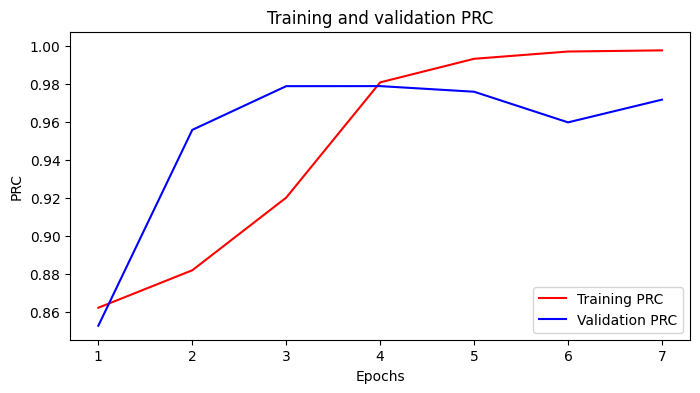

In [44]:
prc = history_dict['prc'] #change here for another metric
val_prc = history_dict['val_prc'] #change here for another metric
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(prc) + 1) #change here for another metric
fig = plt.figure(figsize=(8, 4))
fig.tight_layout()


plt.plot(2, 1)
plt.plot(epochs, prc, 'r', label='Training PRC') #change here for another metric
plt.plot(epochs, val_prc, 'b', label='Validation PRC') #change here for another metric
plt.title('Training and validation PRC') #change here for another metric
plt.xlabel('Epochs')
plt.ylabel('PRC') #change here for another metric
plt.legend(loc='lower right')


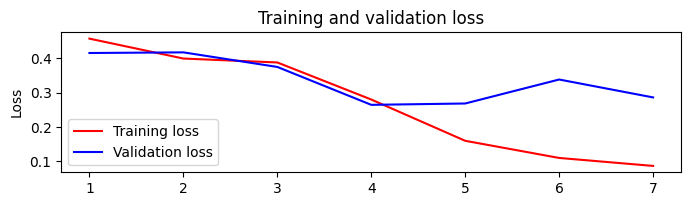

In [45]:
prc = history_dict['prc'] #change here for another metric
val_prc = history_dict['val_prc'] #change here for another metric
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(prc) + 1) #change here for another metric
fig = plt.figure(figsize=(8, 4))
fig.tight_layout()

plt.subplot(2, 1, 1)
# r is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
# plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


**2.2 B (7) Based on your output in 2.2A, discuss and compare the goodness of fit and performance for each of the classification models. Which model is preferred? Why? Explain.**

In comparing the Logistic Regression and Complement Naive Bayes models across testing and training datasets, the Logistic Regression model emerges as the more robust and effective choice. The Logistic Regression model consistently demonstrates higher accuracy, precision, and recall for both classes, signifying its superior ability to make correct predictions and minimize false positives/negatives. The F1-scores, which balance precision and recall, also favor Logistic Regression. Moreover, the area under the ROC curve and the Precision/Recall curve is higher for Logistic Regression, emphasizing its better discriminatory power and overall performance.

In simple terms, Logistic Regression provides a more reliable fit to the data, making it preferable for this particular classification task. While both models exhibit high accuracy, the nuanced evaluation metrics reveal Logistic Regression's superiority in capturing true positives and minimizing false predictions. Choosing Logistic Regression ensures a more effective and accurate classification model, making it the preferred option for practical applications where precise predictions are crucial.

## 2.3 Discussion & Conclusion (10)

**2.3 (10) Briefly summarize the problem statement and data. Then, discuss your analysis and findings. Within the context of the business problem and your analysis results, provide business recommendations. Be sure to discuss any limitations, constraints, or ethical concerns that could impact the implementation of the recommended solution.**

The lotion dataset was used to create predictive models that can help the manufacturer refine their product. The dataset consists of 4,999 reviews of a particular lotion. Date of review, handle (or username), rating on a scale of 1 thru 5, helpfulness rating and written review. The ratings and reviews are the features of interest that were used in generating the predictive models. The goal of generating the predictive models is to determine the current view of the lotion and to determine if future improvements should be made. Although the logistic regression model provided the best results, it is based on data that has a  significant class imbalance. One way to decrease the impact of the class imbalance is to modify the weights of each class and increase the weight of the minority class.